In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [53]:

#csv_path = Path("winrates_itself.csv")
csv_path = Path("winrates_minmax.csv")
df = pd.read_csv(csv_path)


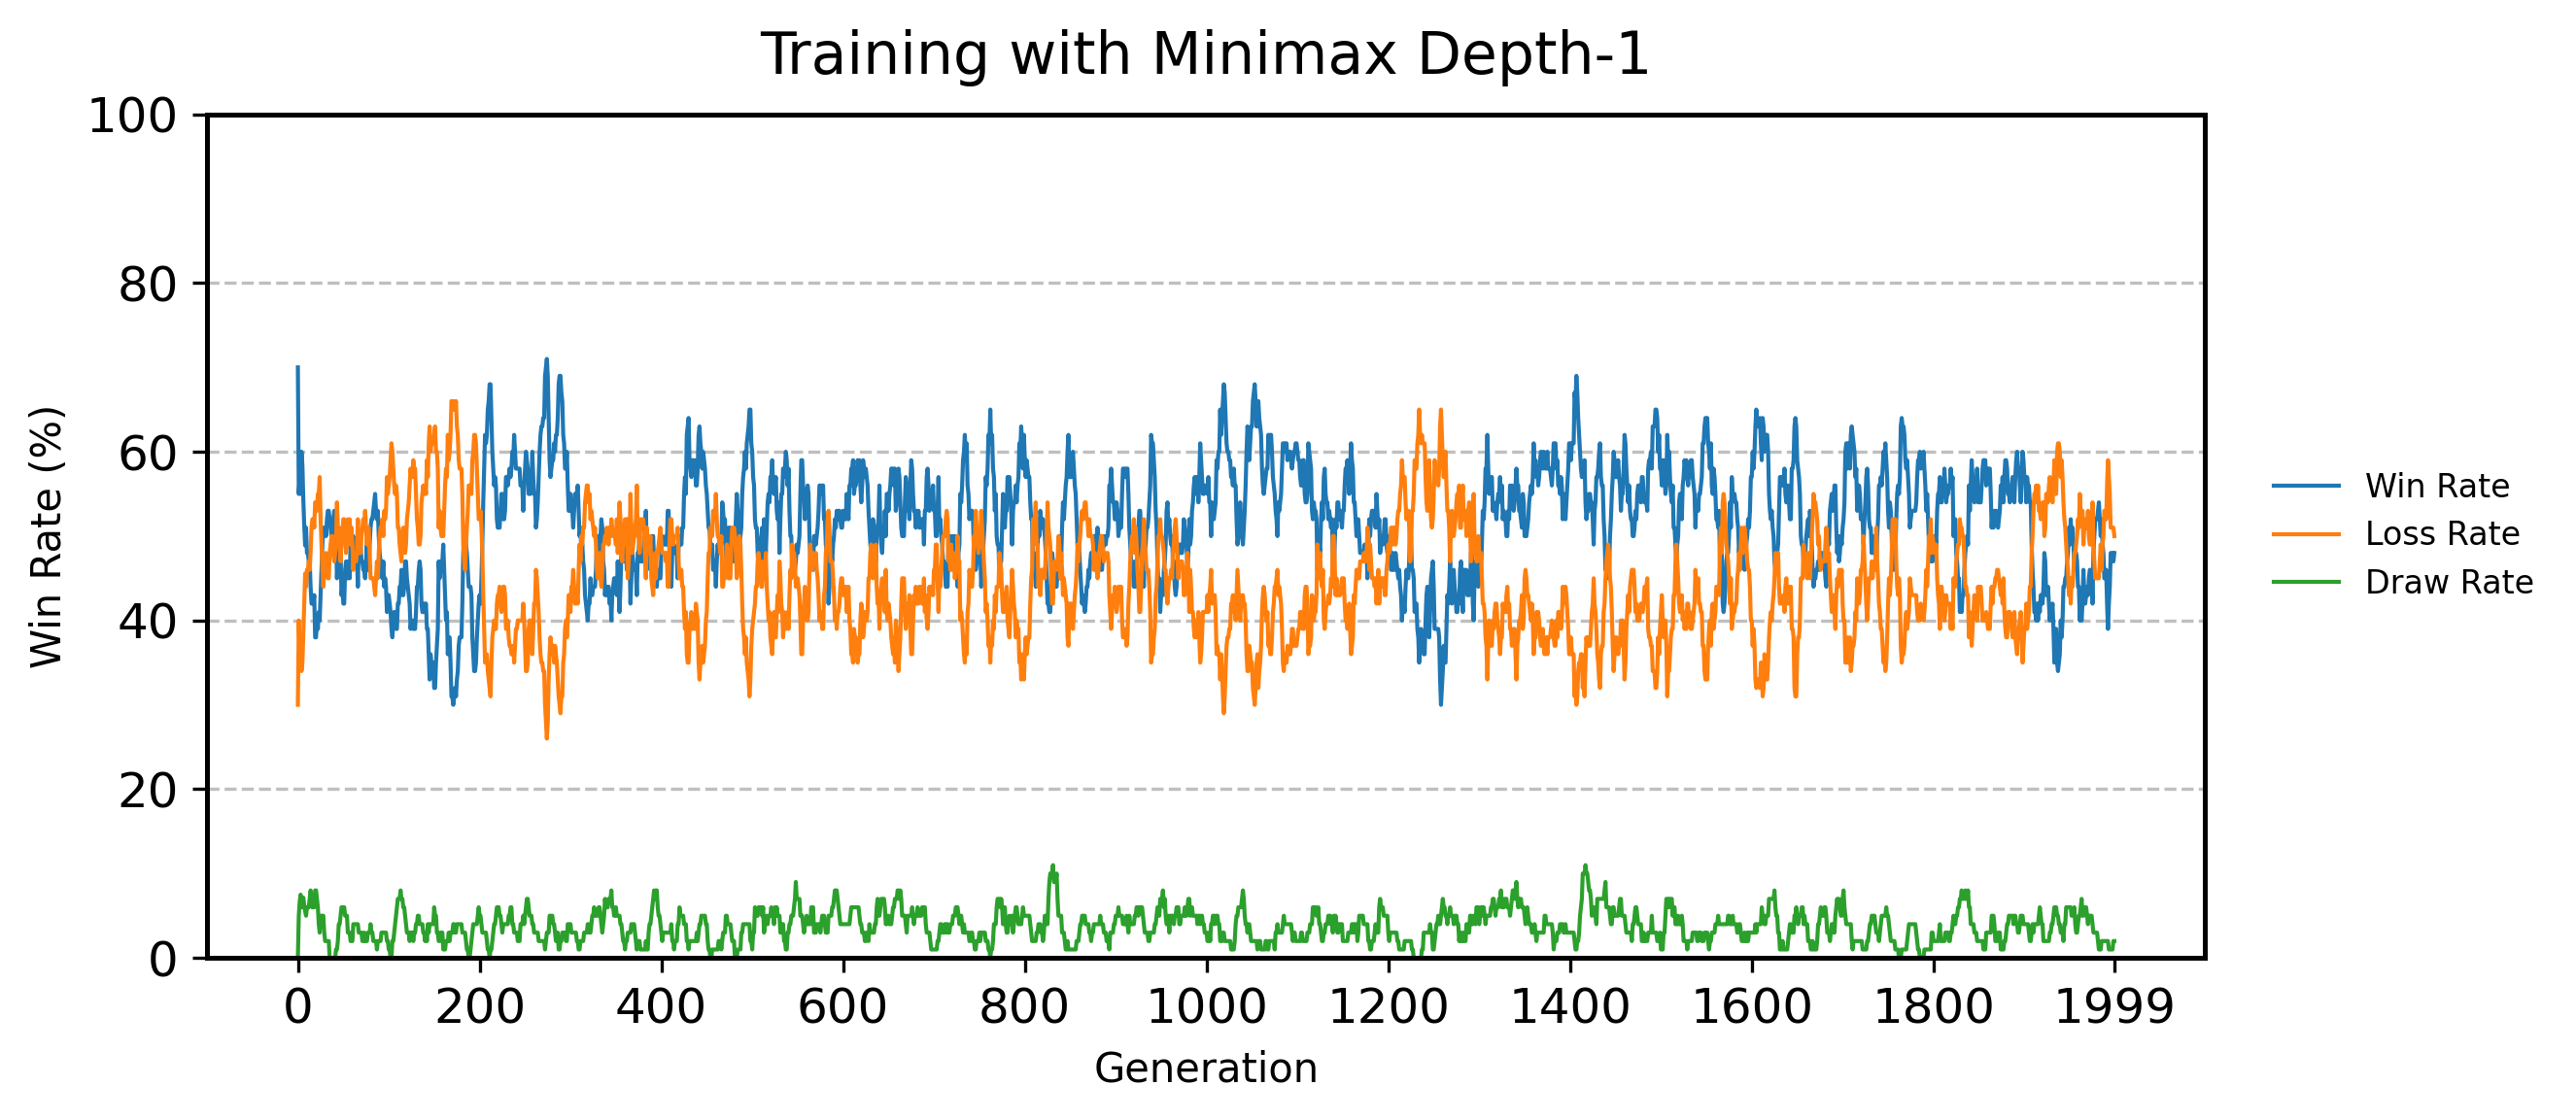

In [54]:
fig, ax = plt.subplots(figsize=(9, 4))  # wider figure to fit legend nicely

rate_cols = ["winrate", "opponent_winrate", "drawrate"]
pretty_names = {
    "winrate": "Win Rate",
    "opponent_winrate": "Loss Rate",
    "drawrate": "Draw Rate"
}

for col in rate_cols:
    smoothed = df[col].rolling(window=10, min_periods=1).mean()
    ax.plot(
        df["generation"],
        smoothed,
        linewidth=1,
        label=pretty_names[col]  # use clean names directly
    )

# Setup xticks: every 50 plus the last generation
xticks = list(df["generation"][::200])
if df["generation"].iloc[-1] not in xticks:
    xticks.append(df["generation"].iloc[-1])

ax.set_xticks(xticks)
ax.set_ylim(0, 100)

# Axis labels (small, not bold)
ax.set_xlabel("Generation", fontsize=10, fontweight='normal')
ax.set_ylabel("Win Rate (%)", fontsize=10, fontweight='normal')

# Title based on file name
title_lookup = {
    "winrates_itself.csv": "Training with Self-Play",
    "stats_vs_random.csv": "DQN Training Against Random Bot",
    "winrates_curriculum.csv": "Training with Curriculum",
    "winrates_random.csv": "Training with Random Bot",
    "winrates_minmax.csv": "Training with Minimax Depth-1",
    # Add more mappings if needed
}
title = title_lookup.get(csv_path.name, "Training Progress")
ax.set_title(title, pad=10)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.5)


# Legend on the right side
ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8
)

fig.tight_layout()
plt.show()
